In [68]:
# ---- Setup ----
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.interpolate as interp

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo
from simplearm.geom import Obstacles
from simplearm.viz import RobotViewer

from utils import get_world_spheres_torch, query_sdf_differentiable
from losses import (
    compute_joint_limits_cost,
    compute_collision_cost,
    compute_smoothness_cost,
    compute_trajectory_collision_cost,
)
from data import build_sdf_tensor, visualize_environment, compute_reference_trajectory
import models

A Robot with the following properties:
  Link Lengths: [0.3 0.4 0.3]
  Number of Spheres: 10
  Mass per Link: [1. 1. 1.]
  Inertia per Link: [0.1 0.1 0.1]
  Number of ignore sphere pairs: 18

Obstacles: 1


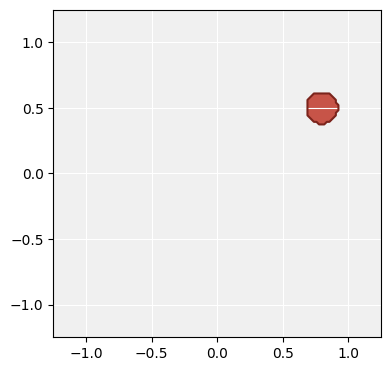

In [70]:
# ---- Robot & Environment ----
GRID_LENGTH = 2.5

linklengths = [0.3, 0.4, 0.3]
robot = RobotInfo.from_linklengths(linklengths, sphere_rad=0.08)
print(robot)

# Single obstacle for interactive experiments — adjust freely
obstacles  = Obstacles(x=np.array([0.8]), y=np.array([0.5]), r=np.array([0.12]))
sdf_tensor = build_sdf_tensor(obstacles, grid_length=GRID_LENGTH)  # [1, H, W]

print(f"\nObstacles: {len(obstacles.r)}")
visualize_environment(sdf_tensor, GRID_LENGTH)

In [71]:
# ---- Visualize random configuration ----
np.random.seed(42)
q_random = np.random.uniform(-np.pi, np.pi, size=(robot.n_dof,))
print(f"Random config: {np.round(q_random, 3)}")

viz = RobotViewer(q_random, robot, obstacles=obstacles)
viz.plot()

Random config: [-0.788  2.832  1.458]
⠋ Plotting robot... (0:00:00.00)

In [72]:
# ---- Visualize cubic spline trajectory ----
n_waypoints = 4
waypoints   = np.random.uniform(-np.pi, np.pi, size=(n_waypoints, robot.n_dof))
cs          = interp.CubicSpline(np.linspace(0, 1, n_waypoints), waypoints, axis=0)
q_trajectory = cs(np.linspace(0, 1, 50))

print(f"Spline trajectory: {len(q_trajectory)} steps")
viz = RobotViewer(q_trajectory, robot, obstacles=obstacles)
viz.plot()

Spline trajectory: 50 steps
⠼ Plotting robot... (0:00:00.64) 

In [73]:
# ---- Evaluate costs for the spline trajectory ----
q_tensor = torch.from_numpy(q_trajectory).float()
q_min    = torch.tensor([-np.pi, -np.pi, -np.pi])
q_max    = torch.tensor([ np.pi,  np.pi,  np.pi])
eps      = 0.1
sdf_hw   = sdf_tensor.squeeze(0)

total_coll = total_jl = 0
for q_step in q_tensor:
    spheres     = get_world_spheres_torch(q_step.unsqueeze(0), robot)
    dists       = query_sdf_differentiable(sdf_hw, spheres.reshape(-1, 2), GRID_LENGTH)
    total_coll += compute_collision_cost(dists, eps=eps, weight=20.0)
    total_jl   += compute_joint_limits_cost(q_step.unsqueeze(0), q_min, q_max)

total_smooth = compute_smoothness_cost(q_tensor, dt=0.02, weight=0.002)

print(f"Joint limits cost: {total_jl.item():.4f}")
print(f"Collision cost:    {total_coll.item():.4f}")
print(f"Smoothness cost:   {total_smooth.item():.4f}")
print(f"Total:             {(total_jl + total_coll + total_smooth).item():.4f}")

Joint limits cost: 8.5986
Collision cost:    0.0000
Smoothness cost:   19.7130
Total:             28.3116


In [79]:
# ---- Single-config gradient descent: escape from obstacle ----
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sdf_dev = sdf_hw.to(device)
q_min_t = torch.tensor([-np.pi, -np.pi, -np.pi], device=device)
q_max_t = torch.tensor([ np.pi,  np.pi,  np.pi], device=device)

q = torch.tensor([0.23 * np.pi, -0.2 * np.pi, 0.3 * np.pi], device=device).requires_grad_(True)
opt = torch.optim.SGD([q], lr=0.002)

trajectory = [q.detach().cpu().numpy().copy()]
it, loss_val = 0, 1000.0

while loss_val > 0.01 and it < 100:
    opt.zero_grad()
    q_step  = q.unsqueeze(0)
    spheres = get_world_spheres_torch(q_step, robot)
    dists   = query_sdf_differentiable(sdf_dev, spheres.view(-1, 2), GRID_LENGTH)
    loss    = (compute_collision_cost(dists, eps=0.1, weight=20.0)
               + compute_joint_limits_cost(q_step, q_min_t, q_max_t))
    loss.backward()
    opt.step()
    with torch.no_grad():
        q[:] = torch.clamp(q, -np.pi, np.pi)
    trajectory.append(q.detach().cpu().numpy().copy())
    loss_val = loss.item()
    it += 1
    if it % 10 == 0:
        print(f"iter {it:3d}  loss={loss_val:.4f}  q={np.round(q.detach().cpu().numpy(), 3)}")

viz = RobotViewer(np.stack(trajectory), robot, obstacles=obstacles)
viz.plot()

iter  10  loss=0.0127  q=[ 0.879 -0.551  1.042]
⠋ Plotting robot... (0:00:00.00)

In [80]:
# ---- WarmStartPlanner inference ----
import importlib
importlib.reload(models)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = models.WarmStartPlanner(dof=3, T=50).to(device)
model.load_state_dict(torch.load("models/warm_start_planner.pt", weights_only=True))
model.eval()

q_start = torch.tensor([[0.0,  0.5, -0.3]], dtype=torch.float32, device=device)
q_goal  = torch.tensor([[1.0, -0.0,  0.8]], dtype=torch.float32, device=device)
sdf_in  = sdf_tensor.unsqueeze(0).to(device)  # [1, 1, H, W]

with torch.no_grad():
    q_traj = model(q_start, q_goal, sdf_in)

print("Trajectory shape:", q_traj.shape)
viz = RobotViewer(q_traj.squeeze(0).cpu().numpy(), robot, obstacles=obstacles)
viz.plot()

Trajectory shape: torch.Size([1, 50, 3])
⠹ Plotting robot... (0:00:00.97) 

In [82]:
# ---- CHOMP trajectory optimization ----
q_start_np = np.array([0.0,  0.5, -0.3])
q_goal_np  = np.array([1.0, -0.4,  0.8])

print("Running CHOMP (5 restarts)...")
q_chomp, success = compute_reference_trajectory(
    q_start_np, q_goal_np, sdf_tensor, robot,
    n_restarts=5, n_iter=600,
)

print(f"Success: {success}")
print(f"Start:   {q_chomp[0].round(3)}")
print(f"Goal:    {q_chomp[-1].round(3)}")

viz = RobotViewer(q_chomp, robot, obstacles=obstacles)
viz.plot()

Running CHOMP (5 restarts)...
Success: True
Start:   [ 0.   0.5 -0.3]
Goal:    [ 1.  -0.4  0.8]
⠋ Plotting robot... (0:00:00.00)

In [83]:
# ---- Visualize a sample from training_dataset ----
dataset = torch.load("data/training_dataset.pt", weights_only=False)
N_ds    = dataset["metadata"]["N"]

robot_ds = RobotInfo.from_linklengths(
    dataset["metadata"]["linklengths"],
    sphere_rad=dataset["metadata"]["sphere_rad"],
)

SAMPLE_IDX = torch.randint(0, N_ds, (1,)).item()

q_start_np    = dataset["q_start"][SAMPLE_IDX].numpy()
q_goal_np     = dataset["q_goal"][SAMPLE_IDX].numpy()
q_traj_ref_np = dataset["q_traj"][SAMPLE_IDX].numpy()

n_obs    = dataset["n_obstacles"][SAMPLE_IDX].item()
obs_data = dataset["obstacles"][SAMPLE_IDX]
obstacles_ds = Obstacles(
    x=obs_data[:n_obs, 0].numpy(),
    y=obs_data[:n_obs, 1].numpy(),
    r=obs_data[:n_obs, 2].numpy(),
)

print(f"Sample {SAMPLE_IDX} / {N_ds}")
print(f"  q_start:   {np.round(q_start_np, 3)}")
print(f"  q_goal:    {np.round(q_goal_np, 3)}")
print(f"  obstacles: {n_obs}")

viz = RobotViewer(q_traj_ref_np, robot_ds, obstacles=obstacles_ds)
viz.plot()

Sample 8 / 21
  q_start:   [-3.003 -0.357  0.972]
  q_goal:    [-2.448  1.578  2.386]
  obstacles: 2
⠹ Plotting robot... (0:00:00.77) 

sdf_dataset shape: torch.Size([12000, 1, 128, 128])  —  showing sample 5454


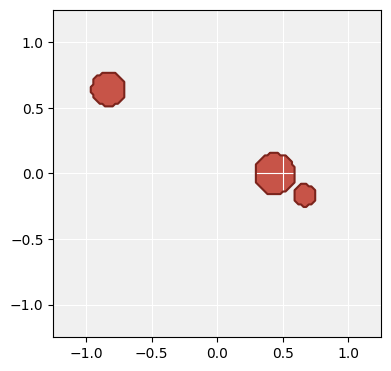

In [84]:
# ---- Visualize a random sample from sdf_dataset ----
sdf_dataset = torch.load("data/sdf_dataset.pt", weights_only=True)
idx         = torch.randint(0, len(sdf_dataset), (1,)).item()

print(f"sdf_dataset shape: {sdf_dataset.shape}  —  showing sample {idx}")
visualize_environment(sdf_dataset[idx], grid_length=GRID_LENGTH)